# Email / SMS Spam Detection Using Machine Learning

## 1. Introduction

This project develops a machine learning system for classifying text messages as either spam or ham (legitimate messages).

The project applies Natural Language Processing (NLP) techniques to transform text into numerical features and trains multiple machine learning classifiers to identify spam messages.

The workflow includes data cleaning, exploratory analysis, text preprocessing, TF-IDF feature extraction, model training, evaluation, and comparison.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

sns.set_theme(style="whitegrid")

In [2]:
import os

print("Files in project folder:")

for file in os.listdir():
    print(file)

Files in project folder:
spam.csv
Task4_Email_Spam_Detection.ipynb


In [3]:
import os

print("Files in project folder:")

for file in os.listdir():
    print(file)

Files in project folder:
spam.csv
Task4_Email_Spam_Detection.ipynb


In [5]:
import pandas as pd

df = pd.read_csv("spam.csv", encoding="latin-1")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (5572, 5)


In [6]:
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [7]:
print(df.columns.tolist())

['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4']


# Email / SMS Spam Detection Using Machine Learning

## 1. Introduction

This project develops a machine learning system for classifying text messages as either spam or ham (legitimate).

Natural Language Processing (NLP) techniques are used to convert text messages into numerical features using TF-IDF. Multiple machine learning classifiers are then trained and compared.

The project includes:

- Data cleaning
- Exploratory data analysis
- Text preprocessing
- TF-IDF feature extraction
- Multinomial Naive Bayes
- Logistic Regression
- Model evaluation
- Confusion matrix
- Error analysis
- Example spam prediction

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

sns.set_theme(style="whitegrid")

In [9]:
df = pd.read_csv(
    "spam.csv",
    encoding="latin-1"
)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (5572, 5)


In [10]:
print("Columns:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

Columns:
['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4']

First 5 rows:


,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [11]:
df = df[["v1", "v2"]]

df.columns = ["label", "message"]

print("Columns after cleaning:")
print(df.columns.tolist())

display(df.head())

Columns after cleaning:
['label', 'message']


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [12]:
print("Missing values:")
print(df.isnull().sum())

Missing values:
label      0
message    0
dtype: int64


In [13]:
df = df.dropna(subset=["label", "message"])

print("Shape after removing missing values:", df.shape)

Shape after removing missing values: (5572, 2)


In [14]:
duplicates = df.duplicated().sum()

print("Duplicate rows:", duplicates)

df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)

Duplicate rows: 403
Shape after removing duplicates: (5169, 2)


In [15]:
print(df["label"].value_counts())

label
ham     4516
spam     653
Name: count, dtype: int64


## 2. Exploratory Data Analysis

### Class Distribution

The dataset contains two classes:

- Ham — legitimate messages
- Spam — unwanted or fraudulent messages

Examining the class distribution helps understand whether the dataset is balanced or imbalanced.

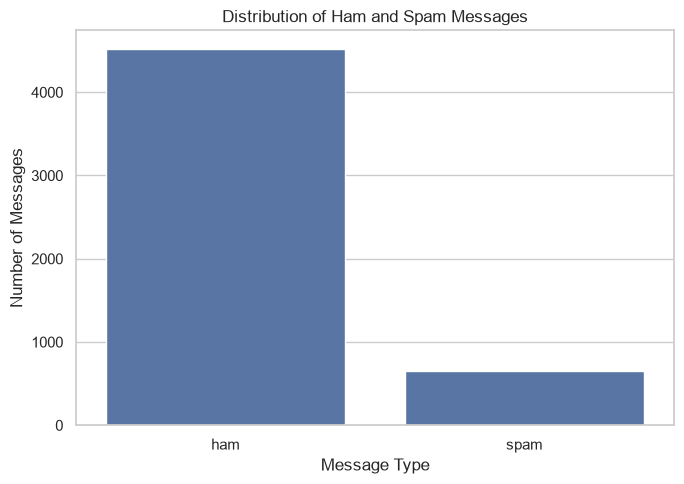

In [16]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="label"
)

plt.title("Distribution of Ham and Spam Messages")
plt.xlabel("Message Type")
plt.ylabel("Number of Messages")

plt.tight_layout()
plt.show()

In [17]:
class_percentages = (
    df["label"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("Class percentages:")
print(class_percentages)

Class percentages:
label
ham     87.37
spam    12.63
Name: proportion, dtype: float64


In [18]:
df["message_length"] = df["message"].str.len()

df[["label", "message", "message_length"]].head()

,label,message,message_length
0,ham,"Go until jurong point, crazy.. Available only ...",111
1,ham,Ok lar... Joking wif u oni...,29
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,ham,U dun say so early hor... U c already then say...,49
4,ham,"Nah I don't think he goes to usf, he lives aro...",61


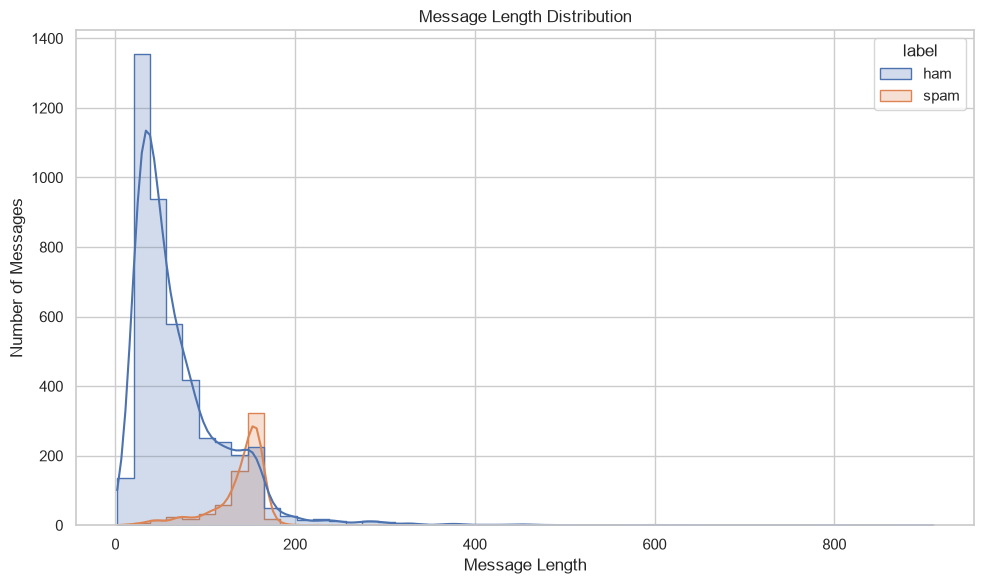

In [19]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="message_length",
    hue="label",
    bins=50,
    kde=True,
    element="step"
)

plt.title("Message Length Distribution")
plt.xlabel("Message Length")
plt.ylabel("Number of Messages")

plt.tight_layout()
plt.show()

In [20]:
average_length = df.groupby("label")["message_length"].mean()

print("Average message length:")
print(average_length)

Average message length:
label
ham      70.459256
spam    137.891271
Name: message_length, dtype: float64


In [21]:
import re

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"\S+@\S+", " ", text)
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    
    return text

In [22]:
import re

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"\S+@\S+", " ", text)
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    
    return text

In [26]:
# ==========================================
# RELOAD + FINAL CLEANING + PREPROCESSING
# ==========================================

import pandas as pd
import re

# Reload the ORIGINAL CSV
df = pd.read_csv(
    "spam.csv",
    encoding="latin-1"
)

print("Original columns:")
print(df.columns.tolist())

# Keep only the original useful columns
df = df[["v1", "v2"]].copy()

# Rename columns
df.columns = ["label", "message"]

# Remove missing values
df = df.dropna(subset=["label", "message"])

# Remove duplicate rows
df = df.drop_duplicates()

# Reset index
df = df.reset_index(drop=True)


# ------------------------------------------
# TEXT CLEANING
# ------------------------------------------

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"\S+@\S+", " ", text)
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    
    return text


df["clean_message"] = df["message"].apply(clean_text)


# ------------------------------------------
# LABEL ENCODING
# ham  -> 0
# spam -> 1
# ------------------------------------------

df["label_encoded"] = df["label"].map({
    "ham": 0,
    "spam": 1
})

# Remove rows where label could not be mapped
df = df.dropna(subset=["label_encoded"])

# Convert to integer
df["label_encoded"] = df["label_encoded"].astype(int)


# ------------------------------------------
# FINAL CHECK
# ------------------------------------------

print("\nCleaning and preprocessing completed! ✅")

print("\nShape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nLabel distribution:")
print(df["label"].value_counts())

print("\nEncoded label distribution:")
print(df["label_encoded"].value_counts())

print("\nFirst 5 rows:")
display(df.head())

Original columns:
['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4']

Cleaning and preprocessing completed! ✅

Shape: (5169, 4)

Columns:
['label', 'message', 'clean_message', 'label_encoded']

Label distribution:
label
ham     4516
spam     653
Name: count, dtype: int64

Encoded label distribution:
label_encoded
0    4516
1     653
Name: count, dtype: int64

First 5 rows:


,label,message,clean_message,label_encoded
0,ham,"Go until jurong point, crazy.. Available only ...",go until jurong point crazy available only in ...,0
1,ham,Ok lar... Joking wif u oni...,ok lar joking wif u oni,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,free entry in a wkly comp to win fa cup final ...,1
3,ham,U dun say so early hor... U c already then say...,u dun say so early hor u c already then say,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",nah i don t think he goes to usf he lives arou...,0


In [27]:
from sklearn.model_selection import train_test_split

X = df["clean_message"]
y = df["label_encoded"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Train/Test split completed! ✅")
print("Training samples:", len(X_train))
print("Testing samples :", len(X_test))

Train/Test split completed! ✅
Training samples: 4135
Testing samples : 1034


In [28]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    stop_words="english",
    ngram_range=(1, 2),
    max_features=10000,
    sublinear_tf=True
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("TF-IDF completed! ✅")
print("Training shape:", X_train_tfidf.shape)
print("Testing shape :", X_test_tfidf.shape)

TF-IDF completed! ✅
Training shape: (4135, 10000)
Testing shape : (1034, 10000)


In [29]:
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()

nb_model.fit(X_train_tfidf, y_train)

y_pred_nb = nb_model.predict(X_test_tfidf)

print("Multinomial Naive Bayes trained successfully! ✅")

Multinomial Naive Bayes trained successfully! ✅


In [30]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr_model.fit(X_train_tfidf, y_train)

y_pred_lr = lr_model.predict(X_test_tfidf)

print("Logistic Regression trained successfully! ✅")

Logistic Regression trained successfully! ✅


In [31]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [32]:
nb_accuracy = accuracy_score(y_test, y_pred_nb)
nb_precision = precision_score(y_test, y_pred_nb)
nb_recall = recall_score(y_test, y_pred_nb)
nb_f1 = f1_score(y_test, y_pred_nb)

print("Multinomial Naive Bayes")
print("----------------------------")
print("Accuracy :", round(nb_accuracy, 4))
print("Precision:", round(nb_precision, 4))
print("Recall   :", round(nb_recall, 4))
print("F1 Score :", round(nb_f1, 4))

Multinomial Naive Bayes
----------------------------
Accuracy : 0.9632
Precision: 1.0
Recall   : 0.7099
F1 Score : 0.8304


In [33]:
lr_accuracy = accuracy_score(y_test, y_pred_lr)
lr_precision = precision_score(y_test, y_pred_lr)
lr_recall = recall_score(y_test, y_pred_lr)
lr_f1 = f1_score(y_test, y_pred_lr)

print("Logistic Regression")
print("----------------------------")
print("Accuracy :", round(lr_accuracy, 4))
print("Precision:", round(lr_precision, 4))
print("Recall   :", round(lr_recall, 4))
print("F1 Score :", round(lr_f1, 4))

Logistic Regression
----------------------------
Accuracy : 0.9516
Precision: 0.988
Recall   : 0.626
F1 Score : 0.7664


In [34]:
model_comparison = pd.DataFrame({
    "Model": [
        "Multinomial Naive Bayes",
        "Logistic Regression"
    ],
    "Accuracy": [
        nb_accuracy,
        lr_accuracy
    ],
    "Precision": [
        nb_precision,
        lr_precision
    ],
    "Recall": [
        nb_recall,
        lr_recall
    ],
    "F1 Score": [
        nb_f1,
        lr_f1
    ]
})

model_comparison.round(4)

,Model,Accuracy,Precision,Recall,F1 Score
0,Multinomial Naive Bayes,0.9632,1.000,0.7099,0.8304
1,Logistic Regression,0.9516,0.988,0.6260,0.7664


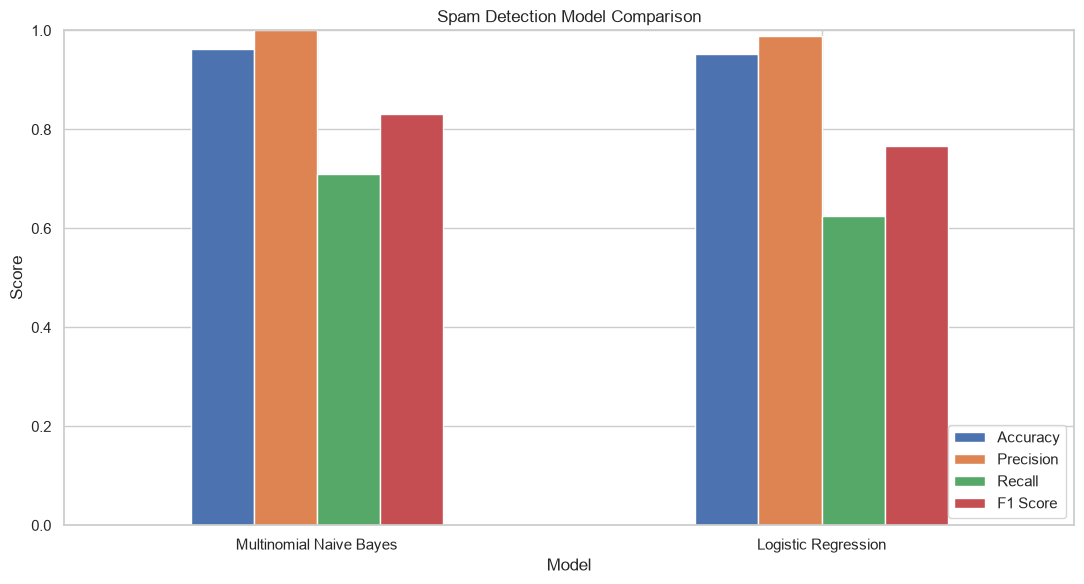

In [35]:
comparison_plot = model_comparison.set_index("Model")

comparison_plot.plot(
    kind="bar",
    figsize=(11, 6)
)

plt.title("Spam Detection Model Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1)

plt.xticks(rotation=0)
plt.legend(loc="lower right")

plt.tight_layout()
plt.show()

In [36]:
best_model_row = model_comparison.loc[
    model_comparison["F1 Score"].idxmax()
]

print("Best Performing Model:")
print(best_model_row)

Best Performing Model:
Model        Multinomial Naive Bayes
Accuracy                     0.96325
Precision                        1.0
Recall                      0.709924
F1 Score                    0.830357
Name: 0, dtype: object


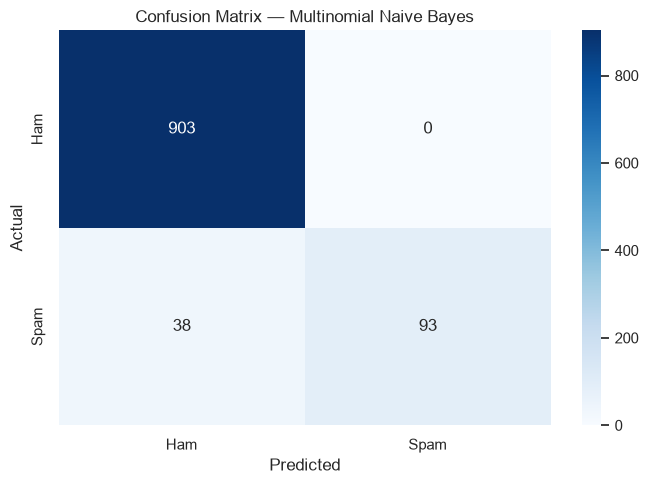

In [37]:
cm_nb = confusion_matrix(
    y_test,
    y_pred_nb
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_nb,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Ham", "Spam"],
    yticklabels=["Ham", "Spam"]
)

plt.title("Confusion Matrix — Multinomial Naive Bayes")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()

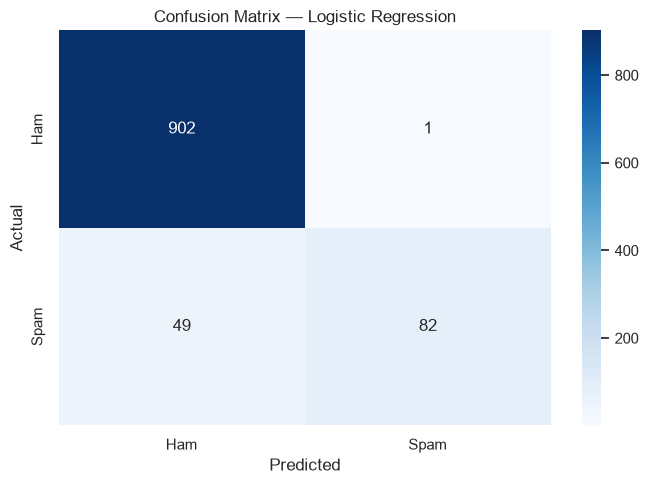

In [38]:
cm_lr = confusion_matrix(
    y_test,
    y_pred_lr
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_lr,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Ham", "Spam"],
    yticklabels=["Ham", "Spam"]
)

plt.title("Confusion Matrix — Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()

In [39]:
print("========== MULTINOMIAL NAIVE BAYES ==========\n")

print(
    classification_report(
        y_test,
        y_pred_nb,
        target_names=["Ham", "Spam"]
    )
)

print("\n========== LOGISTIC REGRESSION ==========\n")

print(
    classification_report(
        y_test,
        y_pred_lr,
        target_names=["Ham", "Spam"]
    )
)

========== MULTINOMIAL NAIVE BAYES ==========

              precision    recall  f1-score   support

         Ham       0.96      1.00      0.98       903
        Spam       1.00      0.71      0.83       131

    accuracy                           0.96      1034
   macro avg       0.98      0.85      0.90      1034
weighted avg       0.96      0.96      0.96      1034


========== LOGISTIC REGRESSION ==========

              precision    recall  f1-score   support

         Ham       0.95      1.00      0.97       903
        Spam       0.99      0.63      0.77       131

    accuracy                           0.95      1034
   macro avg       0.97      0.81      0.87      1034
weighted avg       0.95      0.95      0.95      1034



## Why Recall Matters in Spam Detection

Recall measures the proportion of actual spam messages that are correctly identified by the model.

In spam detection, false negatives are particularly important. A false negative occurs when an actual spam message is incorrectly classified as a legitimate message (ham).

A missed spam message may contain unwanted advertising, phishing attempts, fraudulent offers, or malicious links. Therefore, a spam detection system should aim for high recall so that as many actual spam messages as possible are detected.

However, maximizing recall alone is not enough. Very aggressive spam filtering may incorrectly classify legitimate messages as spam. Therefore, precision and recall must be considered together.

The F1 score provides a balance between precision and recall and is useful for comparing the two classification models.

In [40]:
feature_names = np.array(
    tfidf.get_feature_names_out()
)

nb_log_probs = nb_model.feature_log_prob_[1]

top_spam_indices = np.argsort(
    nb_log_probs
)[-20:][::-1]

top_spam_words = feature_names[
    top_spam_indices
]

print("Important words associated with spam:")
print(top_spam_words)

Important words associated with spam:
['free' 'txt' 'text' 'mobile' 'stop' 'reply' 'claim' 'ur' 'prize' 'new'
 'won' 'cash' 'urgent' 'win' 'send' 'service' 'contact' 'nokia' 'box'
 'just']


In [43]:
from wordcloud import WordCloud

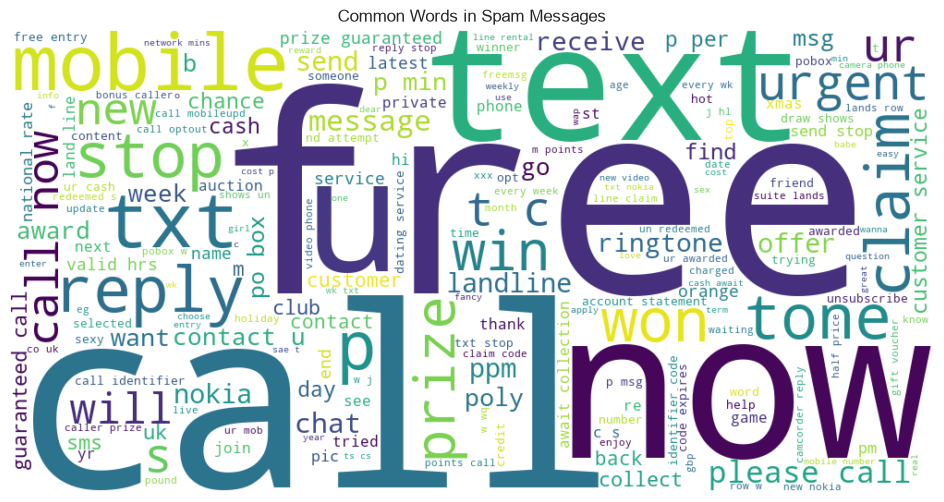

In [44]:
spam_text = " ".join(
    df.loc[df["label"] == "spam", "clean_message"]
)

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white"
).generate(spam_text)

plt.figure(figsize=(12, 6))

plt.imshow(
    wordcloud,
    interpolation="bilinear"
)

plt.axis("off")
plt.title("Common Words in Spam Messages")

plt.show()

In [45]:
def predict_message(message):
    cleaned_message = clean_text(message)

    message_tfidf = tfidf.transform(
        [cleaned_message]
    )

    prediction = lr_model.predict(
        message_tfidf
    )[0]

    probability = lr_model.predict_proba(
        message_tfidf
    )[0].max()

    if prediction == 1:
        result = "SPAM"
    else:
        result = "HAM"

    return result, probability

In [46]:
message = "Hey, are we still meeting for lunch today?"

result, probability = predict_message(message)

print("Message:", message)
print("Prediction:", result)
print("Confidence:", round(probability * 100, 2), "%")

Message: Hey, are we still meeting for lunch today?
Prediction: HAM
Confidence: 96.55 %


In [47]:
message = "Congratulations! You have won a free prize. Click now to claim your reward!"

result, probability = predict_message(message)

print("Message:", message)
print("Prediction:", result)
print("Confidence:", round(probability * 100, 2), "%")

Message: Congratulations! You have won a free prize. Click now to claim your reward!
Prediction: SPAM
Confidence: 83.53 %


In [48]:
final_results = model_comparison.copy()

for column in [
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score"
]:
    final_results[column] = final_results[column].round(4)

final_results

,Model,Accuracy,Precision,Recall,F1 Score
0,Multinomial Naive Bayes,0.9632,1.000,0.7099,0.8304
1,Logistic Regression,0.9516,0.988,0.6260,0.7664


# Conclusion

This project developed an NLP-based machine learning system for detecting spam messages.

The workflow included:

- Data cleaning
- Duplicate removal
- Text preprocessing
- Label encoding
- Train-test splitting
- TF-IDF feature extraction
- Multinomial Naive Bayes
- Logistic Regression
- Accuracy, precision, recall and F1 evaluation
- Confusion matrix analysis
- Spam-associated word analysis
- New-message prediction

The two machine learning models were compared using multiple evaluation metrics.

Recall was given particular importance because false negatives represent actual spam messages that are incorrectly classified as legitimate messages.

The model with the stronger F1 score was selected as the best-performing classifier.

The final system can take a new text message and classify it as either HAM or SPAM.

# Project Summary

### Problem
Classify text messages as spam or legitimate ham messages.

### Dataset
SMS Spam Collection Dataset.

### Target
`label`

- `ham` → 0
- `spam` → 1

### NLP Technique
TF-IDF Vectorization

### Models
- Multinomial Naive Bayes
- Logistic Regression

### Evaluation Metrics
- Accuracy
- Precision
- Recall
- F1 Score
- Confusion Matrix

### Technologies
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn
- WordCloud
- Jupyter Notebook